In [23]:
#MAE 223 Sensor lab readings

# **Module A (Accelerometer)**

##**A1. Static Noise Test**

### **Reflection questions**

This dataset gives you the baseline noise floor.

---

**What value do you expect on each axis?
What does the datasheet predict for zero-g output?**
<br><br>
For a baseline noise floor test, with the senso lying flat, the expected readings are ~0 g on the x and y axis, and -1 g on the z axis, due to gravity. From the time-series plot, the x and y axes are near 0 m/s² and the z axis is near -9.8 m/s². This matched the expected behavior and that the accelerometer is in the correct orientation as is primarily experiencing gravity in the z axis.

---

**How do you quantify noise? What statistic is appropriate, and why?**
<br><br>
Noise can be quantified through different metrics such as noise spectral density, root mean square (RMS) noise, or zero-g bias. For this data collection the best statistic to use for analysis is RMS noise. This is because it provides the spread of the signal around the mean and it gives a direct measurement of the fluctuation in the accelerometer output.

---

**Using the noise spectral density from Table 2 and your measured sample rate, what RMS noise does the datasheet predict?
How does your measurement compare?**
<br><br>
From Table 2 the expected RMS noise is 515µg (0.000515g) RMS and our measured RMS is ~0.067 m/s² (~6.8 mg). This is about 13 times larger than the prediction. The difference is expeceted as the expected noise is assumed under controlled conditions, while the measured data includes additional vibrations, and drift, as we collected the data in a full class where people were walking around.

---

**At what axis orientation is the OLA when flat?
How does this relate to the sign and magnitude of the readings?**
<br><br>
When flat the OLA's z axis is aligned with gravity while the x and y are perpendicular. This means that the OLA would experience gravity in the z direction and would have a negative g reading.

## **A2. Gravity Vector Check (Six-Face Clibration)**

For each axis, the calibration model is:

$$a_{\text{corrected}} = \frac{a_{\text{raw}} - b}{s}$$

where b is the bias (zero-g offset) and s is the scale factor.
Consider:

---

**With two opposing orientations (e.g., +Z up and −Z up), how can you solve for both bias b and scale factor s on the Z-axis?***
<br><br><br>
When +Z is up the true acceleration would be +g and when -Z is usp the true acceleration should be -g.

For the Z-axis:

+Z: $$a_{+} = b + s g$$
-Z: $$a_{-} = b - s g$$

Solving for the bias:
$$b = \frac{a_{+} + a_{-}}{2}$$

Solving for the scale factor:
$$s = \frac{a_{+} - a_{-}}{2g}$$

---

**What should the total acceleration magnitude ‖a‖ equal in every orientation?
Does your data satisfy this?***
<br><br>
The total acceleration magnitude should be equal to gravity in every orientation. This should be the same in every orientation as the sensor is stationary and only measuring gravity.

From the six-face data, the magnitude is close to 9.81 m/s² in each orientation. It's not exact every time but is consistent with the expected values. The difference could be due to noise, scale-factor error or bias.

---

**What does cross-axis coupling look like in the data?
Can you estimate it from your six-face results?**
<br><br>
A cross-axis coupling would be when one axis is aligned with gravity while the other two axes have the same unwanted signal output value. For example when the Z axis experiences gravity while the X and Y axes should be 0 but have the same small nonzero value.
<br><br>

You could estimate it by using

$$\text{Cross-axis coupling} \approx \frac{|\text{off-axis reading}|}{g} \times 100\%$$


##**Part A.1 & A.2 Plots**
* Time-series plot of all three axes

* Noise histogram with expected vs. measured RMS


* Six-face bar chart showing per-axis bias and scale factor

*   Gravity magnitude plot before and after calibration correction



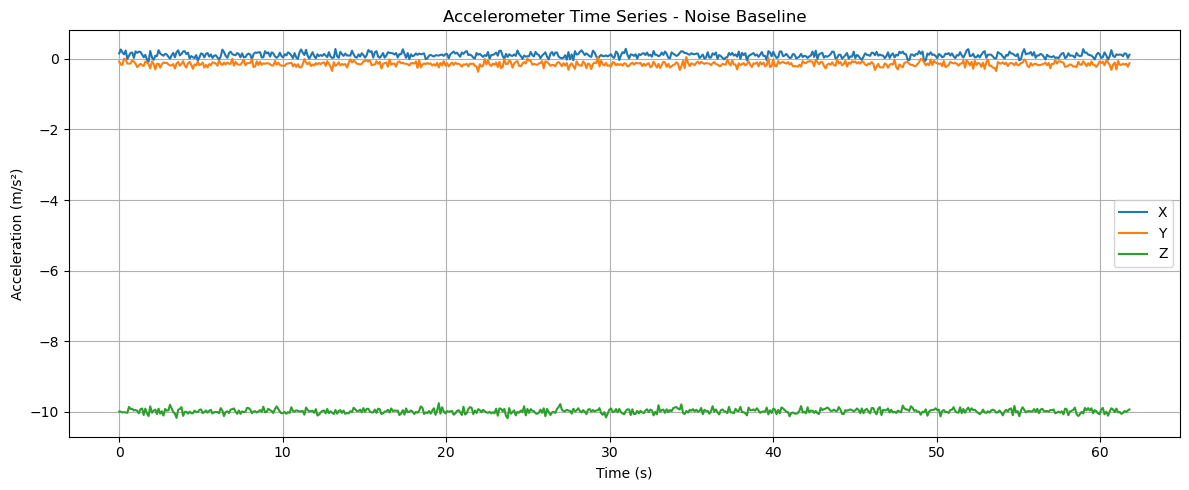

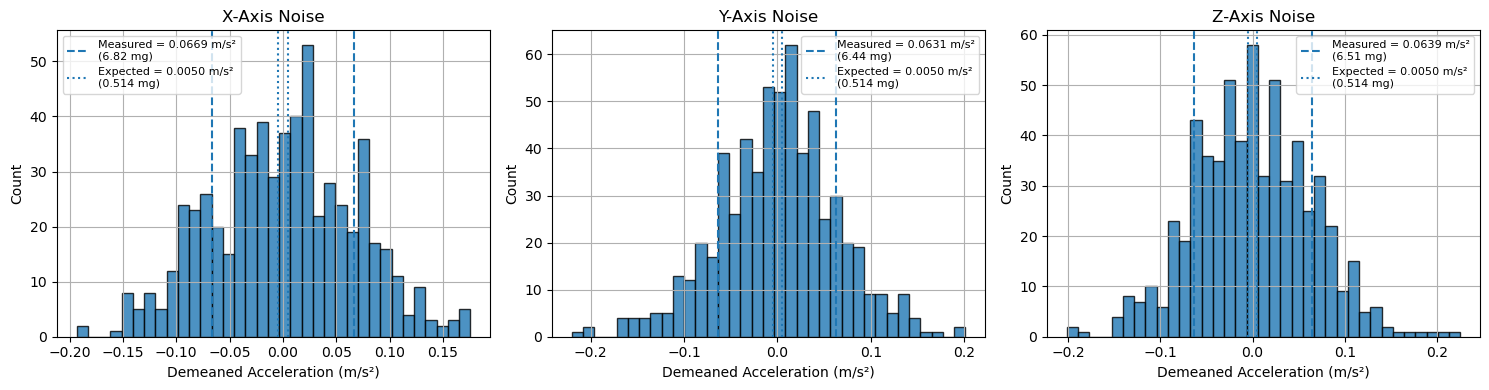


Expected RMS Noise:
0.005045 m/s^2
0.514 mg

Measured RMS Noise:
X: 0.066862 m/s^2   (6.816 mg)
Y: 0.063135 m/s^2   (6.436 mg)
Z: 0.063871 m/s^2   (6.511 mg)


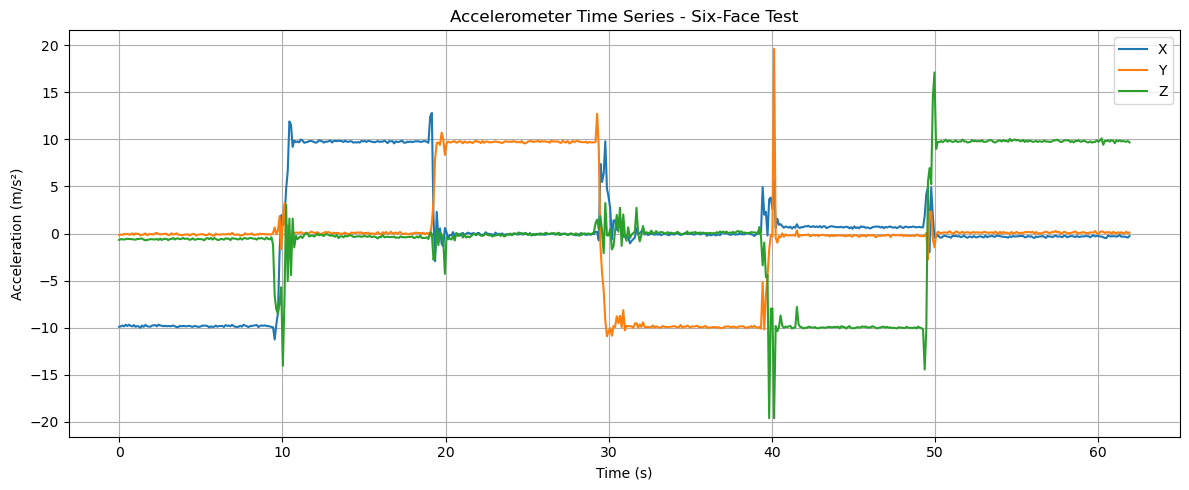


Six-face segment means:
 -X up |   0.0-  9.0 s | mean = [-9.8289, -0.0909, -0.5836]
 +X up |  11.0- 19.0 s | mean = [ 9.7628,  0.0423, -0.3111]
 +Y up |  21.0- 29.0 s | mean = [-0.0647,  9.7313, -0.0987]
 -Y up |  31.0- 39.0 s | mean = [-0.0856, -9.8961,  0.1013]
 -Z up |  41.0- 49.0 s | mean = [ 0.6837, -0.2051, -9.9433]
 +Z up |  51.0- 61.0 s | mean = [-0.3206,  0.1035,  9.8129]

Estimated calibration parameters:
Bias X = -0.033035 m/s^2,   Scale X = 0.998558
Bias Y = -0.082417 m/s^2,   Scale Y = 1.000375
Bias Z = -0.065246 m/s^2,   Scale Z = 1.006942


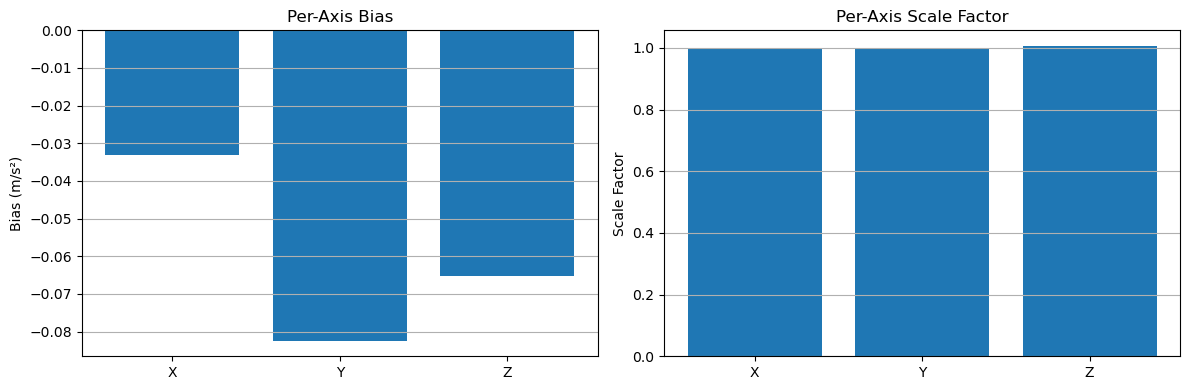

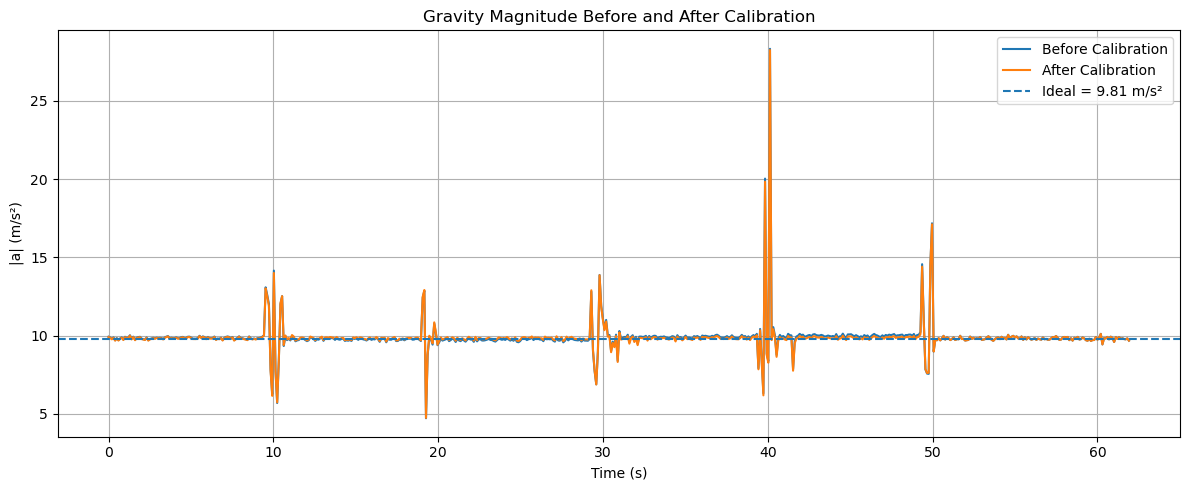

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

g = 9.81  # m/s^2

# ============================================================
# FILES
# ============================================================
noise_file = "Artemis_In_Class_Data/accelerometer_noise_baseline.csv"
sixface_file = "Artemis_In_Class_Data/accelerometer_6axis_tests.csv"

# ============================================================
# DATASHEET EXPECTED NOISE
# Datasheet noise density: 230 ug/sqrt(Hz)
# At fs ~ 10 Hz, effective bandwidth ~ 5 Hz
# Expected RMS = 230 * sqrt(5) ug = 515 ug = 0.515 mg
# ============================================================
expected_rms_mg = 230 * np.sqrt(5) / 1000   # mg
expected_rms = expected_rms_mg / 1000 * g   # m/s^2

# ============================================================
# SIX-FACE SEGMENTS
# Adjust if needed to stay inside flat plateaus
# ============================================================
sixface_segments = [
    (0, 9,   '-X up', np.array([-g,  0,  0])),
    (11, 19, '+X up', np.array([+g,  0,  0])),
    (21, 29, '+Y up', np.array([ 0, +g,  0])),
    (31, 39, '-Y up', np.array([ 0, -g,  0])),
    (41, 49, '-Z up', np.array([ 0,  0, -g])),
    (51, 61, '+Z up', np.array([ 0,  0, +g]))
]

# ============================================================
# LOAD CSV
# Acc columns are in milli-g in the CSV
# Convert mg -> g -> m/s^2
# ============================================================
def load_accel_csv(filename):
    df = pd.read_csv(filename)

    df["Timestamp"] = pd.to_datetime(df["Timestamp"])
    t = (df["Timestamp"] - df["Timestamp"].iloc[0]).dt.total_seconds().to_numpy()

    ax = df["AccX"].to_numpy() / 1000 * g
    ay = df["AccY"].to_numpy() / 1000 * g
    az = df["AccZ"].to_numpy() / 1000 * g

    return t, ax, ay, az

# ============================================================
# BASIC PLOTS
# ============================================================
def plot_time_series(t, ax, ay, az, title):
    plt.figure(figsize=(12, 5))
    plt.plot(t, ax, label="X")
    plt.plot(t, ay, label="Y")
    plt.plot(t, az, label="Z")
    plt.xlabel("Time (s)")
    plt.ylabel("Acceleration (m/s²)")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ============================================================
# NOISE HISTOGRAMS
# Uses standard deviation of demeaned signal
# That is the correct RMS-noise metric here
# ============================================================
def plot_noise_histograms(ax, ay, az, expected_rms):
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    axis_data = {"X": ax, "Y": ay, "Z": az}
    measured_rms = {}

    for i, key in enumerate(["X", "Y", "Z"]):
        data = axis_data[key]

        # Remove mean only
        noise = data - np.mean(data)

        # RMS noise = std of zero-mean signal
        rms = np.std(noise)
        measured_rms[key] = rms

        # Convert to mg too for easier comparison
        rms_mg = rms / g * 1000
        expected_rms_mg_local = expected_rms / g * 1000

        axs[i].hist(noise, bins=35, edgecolor="black", alpha=0.8)

        axs[i].axvline(+rms, linestyle="--",
                       label=f"Measured = {rms:.4f} m/s²\n({rms_mg:.2f} mg)")
        axs[i].axvline(-rms, linestyle="--")

        axs[i].axvline(+expected_rms, linestyle=":",
                       label=f"Expected = {expected_rms:.4f} m/s²\n({expected_rms_mg_local:.3f} mg)")
        axs[i].axvline(-expected_rms, linestyle=":")

        axs[i].set_title(f"{key}-Axis Noise")
        axs[i].set_xlabel("Demeaned Acceleration (m/s²)")
        axs[i].set_ylabel("Count")
        axs[i].grid(True)
        axs[i].legend(fontsize=8)

    plt.tight_layout()
    plt.show()
    return measured_rms

# ============================================================
# SIX-FACE ANALYSIS
# ============================================================
def extract_segment_means(t, ax, ay, az, segments):
    info = []

    for start, end, label, expected in segments:
        mask = (t >= start) & (t <= end)

        mean_x = np.mean(ax[mask])
        mean_y = np.mean(ay[mask])
        mean_z = np.mean(az[mask])

        info.append({
            "label": label,
            "start": start,
            "end": end,
            "expected": expected,
            "mean": np.array([mean_x, mean_y, mean_z])
        })

    return info

def compute_bias_scale(segment_info):
    biases = np.zeros(3)
    scales = np.zeros(3)
    axis_names = ["X", "Y", "Z"]

    for i in range(3):
        plus_val = None
        minus_val = None

        for seg in segment_info:
            if np.isclose(seg["expected"][i], +g):
                plus_val = seg["mean"][i]
            elif np.isclose(seg["expected"][i], -g):
                minus_val = seg["mean"][i]

        if plus_val is None or minus_val is None:
            raise ValueError(f"Missing +g or -g face for axis {axis_names[i]}")

        biases[i] = (plus_val + minus_val) / 2
        scales[i] = (plus_val - minus_val) / (2 * g)

    return biases, scales

def apply_calibration(ax, ay, az, biases, scales):
    ax_c = (ax - biases[0]) / scales[0]
    ay_c = (ay - biases[1]) / scales[1]
    az_c = (az - biases[2]) / scales[2]
    return ax_c, ay_c, az_c

def plot_bias_scale_bar_chart(biases, scales):
    labels = ["X", "Y", "Z"]

    fig, axs = plt.subplots(1, 2, figsize=(12, 4))

    axs[0].bar(labels, biases)
    axs[0].set_title("Per-Axis Bias")
    axs[0].set_ylabel("Bias (m/s²)")
    axs[0].grid(True, axis="y")

    axs[1].bar(labels, scales)
    axs[1].set_title("Per-Axis Scale Factor")
    axs[1].set_ylabel("Scale Factor")
    axs[1].grid(True, axis="y")

    plt.tight_layout()
    plt.show()

def plot_gravity_magnitude(t, ax, ay, az, ax_c, ay_c, az_c):
    mag_raw = np.sqrt(ax**2 + ay**2 + az**2)
    mag_corr = np.sqrt(ax_c**2 + ay_c**2 + az_c**2)

    plt.figure(figsize=(12, 5))
    plt.plot(t, mag_raw, label="Before Calibration")
    plt.plot(t, mag_corr, label="After Calibration")
    plt.axhline(g, linestyle="--", label="Ideal = 9.81 m/s²")
    plt.xlabel("Time (s)")
    plt.ylabel("|a| (m/s²)")
    plt.title("Gravity Magnitude Before and After Calibration")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# ============================================================
# MAIN
# ============================================================

# --------------------------
# 1) Noise baseline
# --------------------------
t_noise, ax_n, ay_n, az_n = load_accel_csv(noise_file)

plot_time_series(t_noise, ax_n, ay_n, az_n,
                 "Accelerometer Time Series - Noise Baseline")

measured_rms = plot_noise_histograms(ax_n, ay_n, az_n, expected_rms)

print("\nExpected RMS Noise:")
print(f"{expected_rms:.6f} m/s^2")
print(f"{expected_rms / g * 1000:.3f} mg")

print("\nMeasured RMS Noise:")
for key in ["X", "Y", "Z"]:
    rms = measured_rms[key]
    rms_mg = rms / g * 1000
    print(f"{key}: {rms:.6f} m/s^2   ({rms_mg:.3f} mg)")

# --------------------------
# 2) Six-face test
# --------------------------
t_6, ax_6, ay_6, az_6 = load_accel_csv(sixface_file)

plot_time_series(t_6, ax_6, ay_6, az_6,
                 "Accelerometer Time Series - Six-Face Test")

segment_info = extract_segment_means(t_6, ax_6, ay_6, az_6, sixface_segments)

print("\nSix-face segment means:")
for seg in segment_info:
    mx, my, mz = seg["mean"]
    print(f"{seg['label']:>6} | {seg['start']:>5.1f}-{seg['end']:>5.1f} s | "
          f"mean = [{mx: .4f}, {my: .4f}, {mz: .4f}]")

biases, scales = compute_bias_scale(segment_info)

print("\nEstimated calibration parameters:")
print(f"Bias X = {biases[0]:.6f} m/s^2,   Scale X = {scales[0]:.6f}")
print(f"Bias Y = {biases[1]:.6f} m/s^2,   Scale Y = {scales[1]:.6f}")
print(f"Bias Z = {biases[2]:.6f} m/s^2,   Scale Z = {scales[2]:.6f}")

plot_bias_scale_bar_chart(biases, scales)

# --------------------------
# 3) Apply calibration
# --------------------------
ax_6_c, ay_6_c, az_6_c = apply_calibration(ax_6, ay_6, az_6, biases, scales)

plot_gravity_magnitude(t_6, ax_6, ay_6, az_6, ax_6_c, ay_6_c, az_6_c)

------------------------------------------------

# **Module B-Gyroscope**

##**B1. Zero-Rate Bias Test**

The mean output on each axis when stationary is the zero-rate output (ZRO) bias. The datasheet specifies initial ZRO of ±5 dps and temperature drift of ±0.05 dps/°C.

Consider:

**What is the measured ZRO bias on each axis? Is it within the ±5 dps spec?**
<br><br>
- GyrX ≈ 1.23 deg/s  
- GyrY ≈ 1.10 deg/s  
- GyrZ ≈ 0.35 deg/s  

All three values are within the ±5 dps spec.

---
<br>

**If you integrate the raw (uncorrected) gyro signal over 120 seconds, how much heading error accumulates?
What about after bias subtraction?**
<br><br>
Using the z axis the heading error is given by

0.35 * 120 = 42°

So the raw gyro signal would accumulate ~42° of heading drift over 120 seconds. After subtracting the measured biar the remaining head error is about 1-2°

---
<br>

**The temperature sensor is also logged. Does the gyro bias change over the 120-second window as the board warms up?
Can you see the correlation?**
<br><br>
During the stationary test the temperature increased from ~25.3°C to ~26.1°C. Ther was no strong visible change in the gyro output over the 120 second window. The correlation would be weak in this dataset compared to how small the dependence is in comparison to the noise.

---
<br>

**How does the gyro noise spectral density (0.015 dps/√Hz) compare to the bias?
Which limits your heading accuracy more over short timescales vs. long timescales?**
<br><br>
The noise spectral density is a lot smaller than the measured bias. This means that over shorter timescales, random noise has more effect. And over long timescales, bias takes over because it integrate


##**B2. Known Rotation Test**

Consider:

* After integrating GyrZ with respect to time, does your computed heading change equal 90°?


* Apply your ZRO bias correction from B1. Does the integrated angle improve?


* What limits the accuracy of gyro-only orientation estimation for a wave buoy that may be rocking continuously for hours?

##**Part B1 and B2 Plots**
* Time-series of all three axes during static test
* ZRO bias estimate per axis with units of dps and equivalent deg/min drift
* Integrated heading from rotation test before and after bias correction

In [25]:
!pip install pandas matplotlib numpy

Estimated sample rate: 10.00 Hz
Estimated dt: 0.1000 s

Detected static test: 0.0 s to 141.79 s
Detected rotation test: 141.89 s to 152.31 s

--- ZRO Bias Results ---
GyrX bias = 1.227 deg/s  (73.6 deg/min)
GyrY bias = 1.101 deg/s  (66.1 deg/min)
GyrZ bias = 0.354 deg/s  (21.3 deg/min)

--- Integrated Heading Results ---
Final raw integrated heading       = 2.35 deg
Final bias-corrected heading       = -1.34 deg
Peak raw heading excursion         = -92.64 deg
Peak bias-corrected excursion      = -93.63 deg


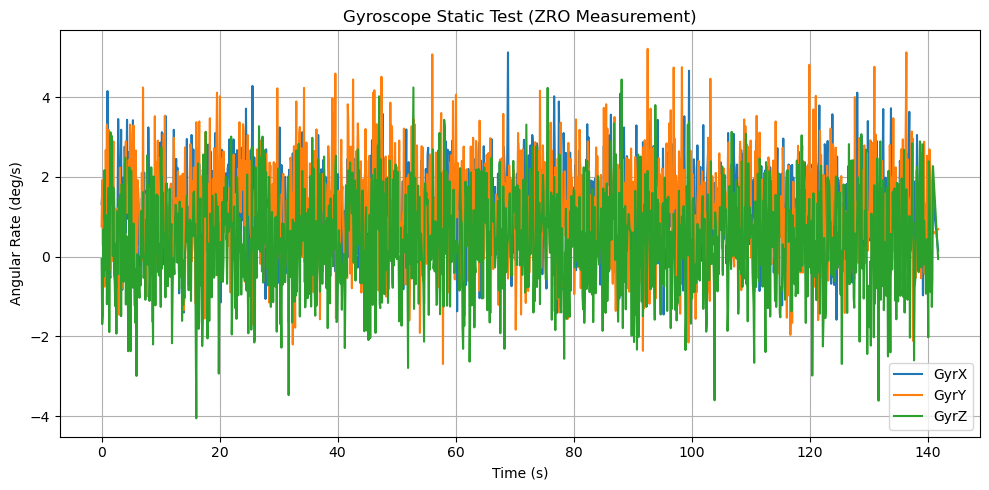

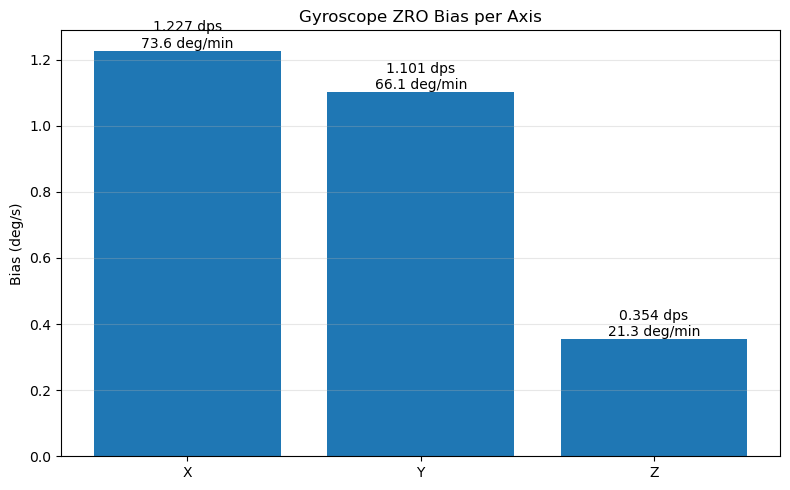

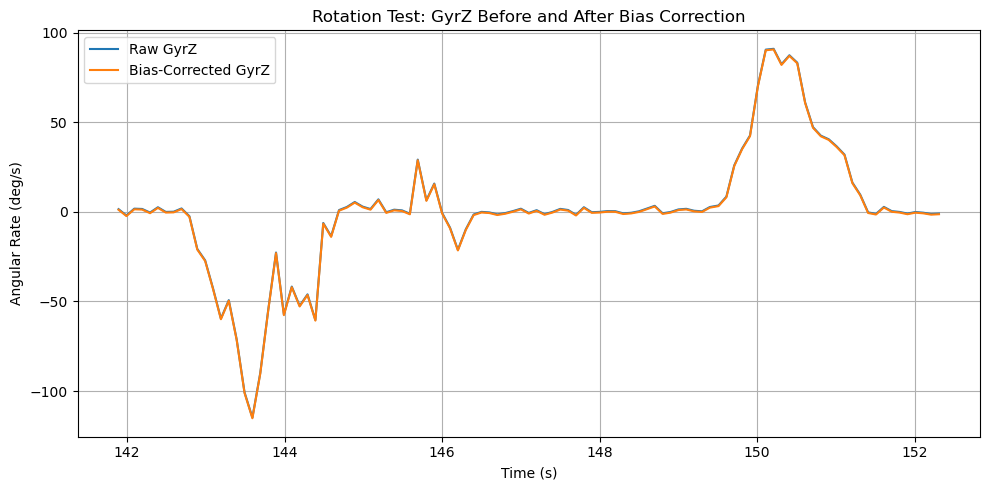

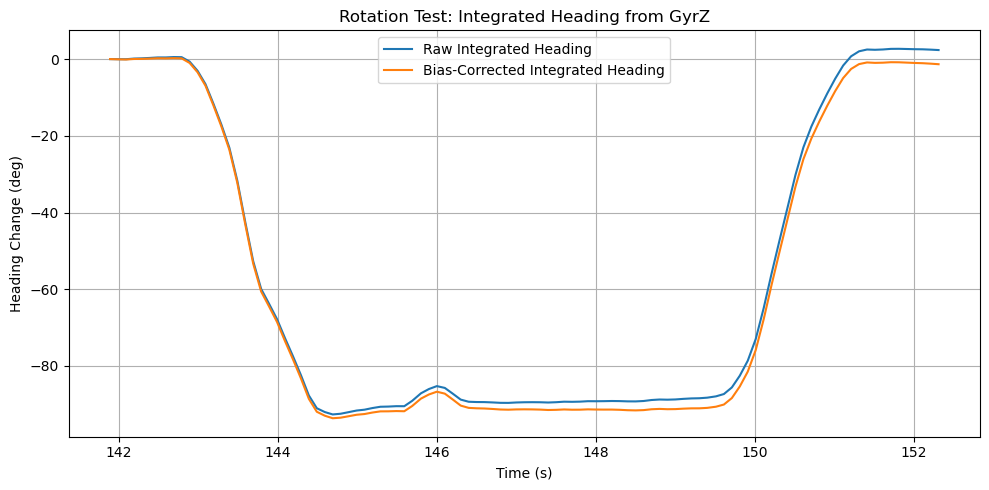

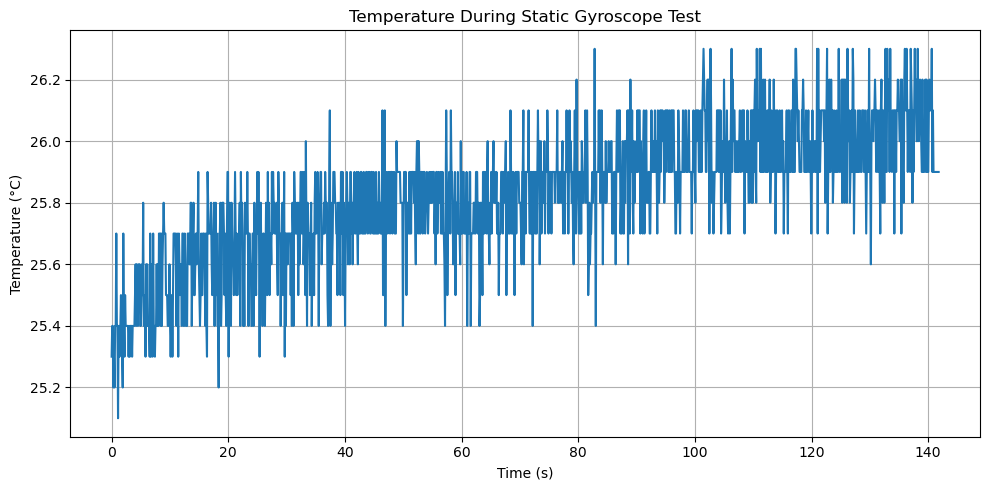


Correlation between temperature and GyrZ during static test: 0.017


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# MODULE B - GYROSCOPE ANALYSIS
# Full replacement script
# ==========================================================

# -----------------------------
# 1. Load data
# -----------------------------
csv_file = "Artemis_In_Class_Data/gyroscope_noise_baseline_and_z_rotation.csv"
df = pd.read_csv(csv_file)

# Convert timestamp to elapsed seconds
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
t = (df["Timestamp"] - df["Timestamp"].iloc[0]).dt.total_seconds().to_numpy()

# Pull gyro columns
gx = df["GyrX"].to_numpy()
gy = df["GyrY"].to_numpy()
gz = df["GyrZ"].to_numpy()

# Optional temperature
temp = df["Temp"].to_numpy() if "Temp" in df.columns else None

# Sampling info
dt = np.median(np.diff(t))
fs = 1.0 / dt

print(f"Estimated sample rate: {fs:.2f} Hz")
print(f"Estimated dt: {dt:.4f} s")

# -----------------------------
# 2. Automatically detect rotation region
# -----------------------------
# Total gyro magnitude
gmag = np.sqrt(gx**2 + gy**2 + gz**2)

# Use first part of data to estimate "still" baseline magnitude
# This assumes the test starts with the static section, which yours does
n_baseline = max(50, int(0.15 * len(gmag)))
baseline_mean = np.mean(gmag[:n_baseline])
baseline_std = np.std(gmag[:n_baseline])

# Threshold for detecting motion
motion_threshold = baseline_mean + 5 * baseline_std

motion_mask = gmag > motion_threshold
motion_indices = np.where(motion_mask)[0]

if len(motion_indices) == 0:
    raise ValueError("No rotation region detected. Try lowering the threshold.")

# Add a buffer before and after motion so whole event gets included
buffer_sec = 1.0
buffer_n = int(buffer_sec / dt)

rot_start_idx = max(0, motion_indices[0] - buffer_n)
rot_end_idx = min(len(t) - 1, motion_indices[-1] + buffer_n)

# Static test is everything before rotation starts
static_mask = t < t[rot_start_idx]
rotation_mask = (np.arange(len(t)) >= rot_start_idx) & (np.arange(len(t)) <= rot_end_idx)

# Extract static region
t_static = t[static_mask]
gx_static = gx[static_mask]
gy_static = gy[static_mask]
gz_static = gz[static_mask]
temp_static = temp[static_mask] if temp is not None else None

# Extract rotation region
t_rot = t[rotation_mask]
gx_rot = gx[rotation_mask]
gy_rot = gy[rotation_mask]
gz_rot = gz[rotation_mask]

print(f"\nDetected static test: 0.0 s to {t_static[-1]:.2f} s")
print(f"Detected rotation test: {t_rot[0]:.2f} s to {t_rot[-1]:.2f} s")

# -----------------------------
# 3. ZRO bias calculation
# -----------------------------
bias_x = np.mean(gx_static)
bias_y = np.mean(gy_static)
bias_z = np.mean(gz_static)

drift_x_degmin = bias_x * 60.0
drift_y_degmin = bias_y * 60.0
drift_z_degmin = bias_z * 60.0

print("\n--- ZRO Bias Results ---")
print(f"GyrX bias = {bias_x:.3f} deg/s  ({drift_x_degmin:.1f} deg/min)")
print(f"GyrY bias = {bias_y:.3f} deg/s  ({drift_y_degmin:.1f} deg/min)")
print(f"GyrZ bias = {bias_z:.3f} deg/s  ({drift_z_degmin:.1f} deg/min)")

# -----------------------------
# 4. Integrate GyrZ during rotation test
# -----------------------------
def cumulative_trapezoid_manual(y, x):
    out = np.zeros_like(y)
    for i in range(1, len(y)):
        out[i] = out[i - 1] + 0.5 * (y[i] + y[i - 1]) * (x[i] - x[i - 1])
    return out

# Raw heading
heading_raw = cumulative_trapezoid_manual(gz_rot, t_rot)

# Bias-corrected heading
gz_rot_corrected = gz_rot - bias_z
heading_corrected = cumulative_trapezoid_manual(gz_rot_corrected, t_rot)

print("\n--- Integrated Heading Results ---")
print(f"Final raw integrated heading       = {heading_raw[-1]:.2f} deg")
print(f"Final bias-corrected heading       = {heading_corrected[-1]:.2f} deg")

# Also estimate peak excursion, which may be closer to the 90° turn than net final value
raw_peak = heading_raw[np.argmax(np.abs(heading_raw))]
corr_peak = heading_corrected[np.argmax(np.abs(heading_corrected))]

print(f"Peak raw heading excursion         = {raw_peak:.2f} deg")
print(f"Peak bias-corrected excursion      = {corr_peak:.2f} deg")

# -----------------------------
# 5. Plot 1: Static gyro time series
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(t_static, gx_static, label="GyrX")
plt.plot(t_static, gy_static, label="GyrY")
plt.plot(t_static, gz_static, label="GyrZ")
plt.xlabel("Time (s)")
plt.ylabel("Angular Rate (deg/s)")
plt.title("Gyroscope Static Test (ZRO Measurement)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 6. Plot 2: ZRO bias bar chart
# -----------------------------
axes = ["X", "Y", "Z"]
bias_vals = [bias_x, bias_y, bias_z]
drift_vals = [drift_x_degmin, drift_y_degmin, drift_z_degmin]

plt.figure(figsize=(8, 5))
bars = plt.bar(axes, bias_vals)
plt.ylabel("Bias (deg/s)")
plt.title("Gyroscope ZRO Bias per Axis")
plt.grid(True, axis="y", alpha=0.3)

for i, b in enumerate(bars):
    plt.text(
        b.get_x() + b.get_width() / 2,
        b.get_height(),
        f"{bias_vals[i]:.3f} dps\n{drift_vals[i]:.1f} deg/min",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

# -----------------------------
# 7. Plot 3: Rotation test gyro rate (Z axis)
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(t_rot, gz_rot, label="Raw GyrZ")
plt.plot(t_rot, gz_rot_corrected, label="Bias-Corrected GyrZ")
plt.xlabel("Time (s)")
plt.ylabel("Angular Rate (deg/s)")
plt.title("Rotation Test: GyrZ Before and After Bias Correction")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 8. Plot 4: Integrated heading
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(t_rot, heading_raw, label="Raw Integrated Heading")
plt.plot(t_rot, heading_corrected, label="Bias-Corrected Integrated Heading")
plt.xlabel("Time (s)")
plt.ylabel("Heading Change (deg)")
plt.title("Rotation Test: Integrated Heading from GyrZ")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -----------------------------
# 9. Optional: temperature during static test
# -----------------------------
if temp is not None:
    plt.figure(figsize=(10, 5))
    plt.plot(t_static, temp_static)
    plt.xlabel("Time (s)")
    plt.ylabel("Temperature (°C)")
    plt.title("Temperature During Static Gyroscope Test")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Simple correlation with Z gyro during static test
    if len(temp_static) == len(gz_static) and len(temp_static) > 2:
        corr = np.corrcoef(temp_static, gz_static)[0, 1]
        print(f"\nCorrelation between temperature and GyrZ during static test: {corr:.3f}")

<br>

---
---
---
<br><br>

# **Module C- Magnetometer** (if you want extra credit figure out the soft-iron correction)

* 2D scatter plots: MagX vs. MagY and MagX vs. MagZ, before and after hard-iron correction
* Field magnitude histogram (target: ~47 µT total at San Diego)
* Heading estimate before and after calibration

**C1. Raw Field Measurement**

In [27]:
import csv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.linalg import sqrtm

#path = '../ola_data/magcaldata.csv'
path = 'Artemis_In_Class_Data/magcaldata.csv'

rows = []
with open(path, newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        rows.append({k: float(v) if k not in ('Timestamp', 'Sensor') else v
                     for k, v in row.items()})

print(f'Loaded {len(rows)} samples')

mx = [r['MagX'] for r in rows]
my = [r['MagY'] for r in rows]
mz = [r['MagZ'] for r in rows]
t  = list(range(len(rows)))
data = np.column_stack([mx, my, mz])

Loaded 1144 samples


In [28]:
# magcal — magnetometer calibration (hard iron + soft iron)
# Port of the MathWorks MATLAB magcal function (Copyright 2018-2022 MathWorks).
#
# Usage:
#   A, b, magB = magcal(data)          # auto-select best fit
#   A, b, magB = magcal(data, 'eye')   # hard iron only
#   A, b, magB = magcal(data, 'diag')  # diagonal soft iron
#   A, b, magB = magcal(data, 'sym')   # full symmetric soft iron
#
#   corrected = (data - b) @ A

def _smallest_eigenvector(d):
    _, _, Vt = np.linalg.svd(d, full_matrices=False)
    return Vt[-1]

def _residual(Winv, V, B, data):
    spherept = (Winv @ (data.T - V.reshape(3, 1))).T
    return np.sum(spherept ** 2, axis=1) - B ** 2

def _is_pd(A):
    try:
        np.linalg.cholesky(A)
        return True
    except np.linalg.LinAlgError:
        return False

def _correct4(x, y, z):
    """4-parameter fit: A = I (hard iron offset only)."""
    bv = x**2 + y**2 + z**2
    A_mat = np.column_stack([x, y, z, np.ones(len(x))])
    soln, _, _, _ = np.linalg.lstsq(A_mat, bv, rcond=None)
    Winv = np.eye(3)
    V = 0.5 * soln[:3]
    B = np.sqrt(soln[3] + np.sum(V**2))
    res = A_mat @ soln - bv
    er = (1.0 / (2.0 * B * B)) * np.sqrt(res @ res / len(x))
    return Winv, V, B, er, True

def _correct7(x, y, z):
    """7-parameter fit: A = diagonal (diagonal soft iron)."""
    d = np.column_stack([x**2, y**2, z**2, x, y, z, np.ones(len(x))])
    beta = _smallest_eigenvector(d)
    A = np.diag(beta[:3])
    dA = beta[0] * beta[1] * beta[2]
    if dA < 0:
        A, beta, dA = -A, -beta, -dA
    V = -0.5 * (beta[3:6] / beta[:3])
    B = np.sqrt(abs(A[0,0]*V[0]**2 + A[1,1]*V[1]**2 + A[2,2]*V[2]**2 - beta[-1]))
    det3root = dA ** (1/3)
    Winv = sqrtm(A / det3root).real
    B /= np.sqrt(det3root)
    res = _residual(Winv, V, B, np.column_stack([x, y, z]))
    er = float(np.real((1.0 / (2*B*B)) * np.sqrt(res @ res / len(x))))
    return Winv, V, B, er, _is_pd(A)

def _correct10(x, y, z):
    """10-parameter fit: A = symmetric (full soft iron)."""
    d = np.column_stack([x*x, 2*x*y, 2*x*z, y*y, 2*y*z, z*z, x, y, z, np.ones(len(x))])
    beta = _smallest_eigenvector(d)
    A = np.array([[beta[0], beta[1], beta[2]],
                  [beta[1], beta[3], beta[4]],
                  [beta[2], beta[4], beta[5]]])
    dA = np.linalg.det(A)
    if dA < 0:
        A, beta, dA = -A, -beta, -dA
    V = -0.5 * np.linalg.solve(A, beta[6:9])
    B = np.sqrt(abs(A[0,0]*V[0]**2 + 2*A[1,0]*V[1]*V[0] + 2*A[2,0]*V[2]*V[0]
                  + A[1,1]*V[1]**2 + 2*A[2,1]*V[1]*V[2] + A[2,2]*V[2]**2 - beta[-1]))
    det3root = dA ** (1/3)
    Winv = sqrtm(A / det3root).real
    B /= np.sqrt(det3root)
    res = _residual(Winv, V, B, np.column_stack([x, y, z]))
    er = float(np.real((1.0 / (2*B*B)) * np.sqrt(res @ res / len(x))))
    return Winv, V, B, er, _is_pd(A)

def magcal(d, fitkind='auto'):
    d = np.asarray(d, dtype=float)
    if d.ndim != 2 or d.shape[1] != 3:
        raise ValueError("d must be an N×3 array")
    x, y, z = d[:,0], d[:,1], d[:,2]
    fitters = {'eye': _correct4, 'diag': _correct7, 'sym': _correct10}
    if fitkind in fitters:
        A, b, magB, _, _ = fitters[fitkind](x, y, z)
    elif fitkind == 'auto':
        A, b, magB, er, _ = _correct4(x, y, z)
        for fn in (_correct7, _correct10):
            Ai, bi, magBi, eri, ispd = fn(x, y, z)
            if ispd and np.all(np.isreal(Ai)) and eri < er:
                A, b, magB, er = Ai, bi, magBi, eri
    else:
        raise ValueError("fitkind must be 'eye', 'diag', 'sym', or 'auto'")
    return A, np.asarray(b).flatten(), magB

print('magcal ready')

magcal ready


## Step 2 — Plot the raw magnetometer data

A well-sampled, uncalibrated magnetometer traces an **off-center ellipsoid** in 3D space. The offset from the origin is caused by hard iron distortion (permanent magnetic fields near the sensor). Your goal is to find and remove that offset so the data forms a sphere centered at the origin.

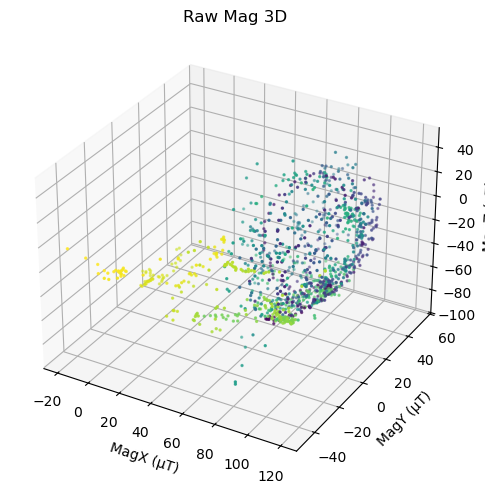

In [29]:
# 3D scatter — raw data
fig = plt.figure(figsize=(6, 5))
ax3d = fig.add_subplot(111, projection='3d')
ax3d.scatter(mx, my, mz, s=2, c=t, cmap='viridis')
ax3d.set_title('Raw Mag 3D')
ax3d.set_xlabel('MagX (µT)')
ax3d.set_ylabel('MagY (µT)')
ax3d.set_zlabel('MagZ (µT)')
plt.tight_layout()
plt.show()

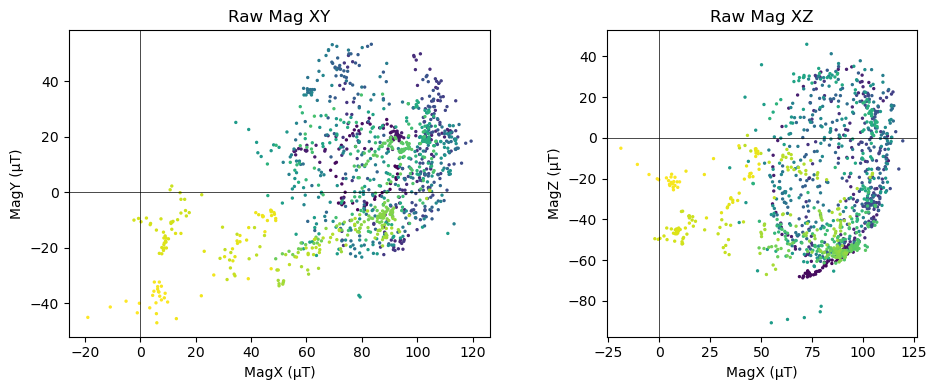

In [30]:
# XY and XZ projections — raw data
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(mx, my, s=2, c=t, cmap='viridis')
axes[0].set_aspect('equal')
axes[0].set_title('Raw Mag XY')
axes[0].set_xlabel('MagX (µT)'); axes[0].set_ylabel('MagY (µT)')
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

axes[1].scatter(mx, mz, s=2, c=t, cmap='viridis')
axes[1].set_aspect('equal')
axes[1].set_title('Raw Mag XZ')
axes[1].set_xlabel('MagX (µT)'); axes[1].set_ylabel('MagZ (µT)')
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

## Step 3 — Compute hard iron offsets

The hard iron offset on each axis is the midpoint between the maximum and minimum values measured:

$$\text{offset}_x = \frac{\max(X) + \min(X)}{2}$$

Repeat for Y and Z. Fill in the cells below.

In [31]:
# TODO: compute the min and max for each axis
mx_min = min(mx)
mx_max = max(mx)

my_min = min(my)
my_max = max(my)

mz_min = min(mz)
mz_max = max(mz)

print(f'MagX range: {mx_min:.2f} to {mx_max:.2f} µT')
print(f'MagY range: {my_min:.2f} to {my_max:.2f} µT')
print(f'MagZ range: {mz_min:.2f} to {mz_max:.2f} µT')

MagX range: -18.90 to 119.40 µT
MagY range: -47.10 to 53.40 µT
MagZ range: -90.75 to 45.90 µT


In [32]:
# TODO: compute the hard iron offsets (midpoint of each axis range)
offset_x = (mx_max + mx_min) / 2
offset_y = (my_max + my_min) / 2
offset_z = (mz_max + mz_min) / 2

print(f'Hard iron offsets: X={offset_x:.3f}, Y={offset_y:.3f}, Z={offset_z:.3f} µT')

Hard iron offsets: X=50.250, Y=3.150, Z=-22.425 µT


## Step 4 — Apply the calibration

Subtract the offsets from the raw measurements to center the data at the origin.

In [33]:
# TODO: apply the offsets to produce calibrated mag vectors
mx_cal = [x - offset_x for x in mx]
my_cal = [y - offset_y for y in my]
mz_cal = [z - offset_z for z in mz]

## Step 5 — Plot the calibrated data

After calibration the 3D scatter should look like a sphere centered near the origin. If it still looks like an ellipsoid (stretched in one direction), you may need soft iron correction too.

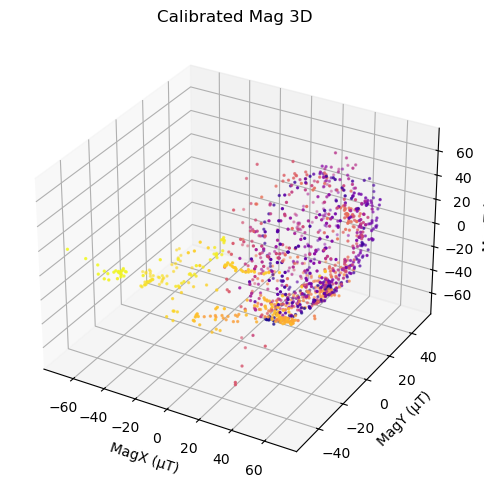

In [34]:
# 3D scatter — calibrated
fig = plt.figure(figsize=(6, 5))
ax3d = fig.add_subplot(111, projection='3d')
ax3d.scatter(mx_cal, my_cal, mz_cal, s=2, c=t, cmap='plasma')
ax3d.set_title('Calibrated Mag 3D')
ax3d.set_xlabel('MagX (µT)')
ax3d.set_ylabel('MagY (µT)')
ax3d.set_zlabel('MagZ (µT)')
plt.tight_layout()
plt.show()

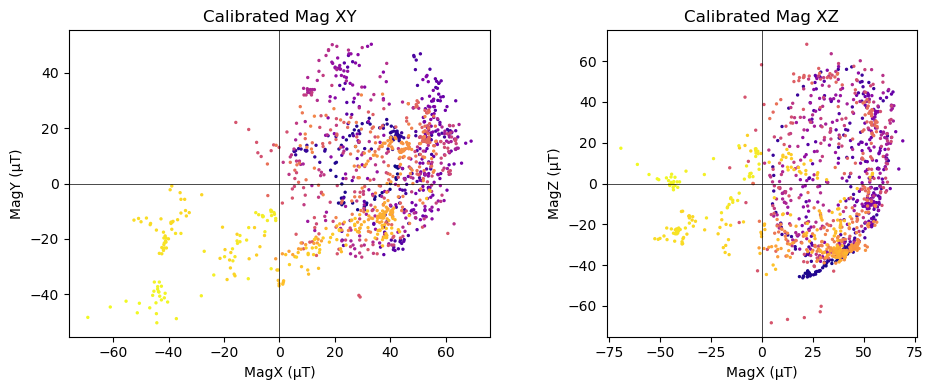

In [35]:
# XY and XZ projections — calibrated
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].scatter(mx_cal, my_cal, s=2, c=t, cmap='plasma')
axes[0].set_aspect('equal')
axes[0].set_title('Calibrated Mag XY')
axes[0].set_xlabel('MagX (µT)'); axes[0].set_ylabel('MagY (µT)')
axes[0].axhline(0, color='k', lw=0.5); axes[0].axvline(0, color='k', lw=0.5)

axes[1].scatter(mx_cal, mz_cal, s=2, c=t, cmap='plasma')
axes[1].set_aspect('equal')
axes[1].set_title('Calibrated Mag XZ')
axes[1].set_xlabel('MagX (µT)'); axes[1].set_ylabel('MagZ (µT)')
axes[1].axhline(0, color='k', lw=0.5); axes[1].axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

## Step 8 — Record your calibration values

Record both sets of results. You will use the `magcal` values in the sensor fusion notebook and firmware.

### Hard iron offsets

| Axis | Simple (midpoint) | magcal |
|------|-------------------|--------|
| X    |        50.250           |   59.725     |
| Y    |        3.150           |    6.680    |
| Z    |        -22.425           |  -15.195      |

### Soft iron correction matrix (A)

```
[[ _1.000____0__  ___0____  ___0____ ]
 [ ___0____  ____1.000___  ____0___ ]
 [ ___0____  ___0____  ___1.000____ ]]
```

Expected field strength: ____48.875___ µT

**Discussion questions:**
1. **How close are your manual hard iron offsets to the `magcal` values?**
   
     The manual hard iron offsets are not very close to the magcal values. The differences can be calculated directly from the two columns. For the X axis, the midpoint estimate is 50.250 µT while magcal gives 59.725 µT, so the difference is
59.725−50.250=9.475 μT

For the Y axis, the midpoint estimate is 3.150 µT and magcal gives 6.680 µT, so

6.680−3.150=3.530 μT

For the Z axis, the midpoint estimate is -22.425 µT and magcal gives -15.195 µT, so

−15.195−(−22.425)=7.230 μT

These are fairly large differences, especially on X and Z. That suggests the simple midpoint method isn’t very accurate for this dataset. The most likely reason is that the sensor wasn‘t rotated through all orientations, so the measured max and min values don’t represent the true limits of the magnetic field. As a result, the midpoint estimate is biased.

2. **Is the soft iron matrix `A` close to identity? What does that tell you about the sensor environment?**

   Yes. The soft iron matrix is essentially the identity matrix:
[[1,0,0],
 [0,1,0],
 [0,0,1]]

That means the calibration didn‘t detect significant stretching or rotation of the magnetic field. Either there is very little nearby ferromagnetic material, or more likely, the dataset is too incomplete to estimate soft iron effects reliably.

3. **Does the `magcal` XY projection look rounder than the simple correction? Why or why not?**

Not really. The magcal XY plot is only slightly rounder than the simple midpoint correction. The main problem is that the data itself is poor: the sensor wasn‘t rotated through a full set of orientations, so both methods are trying to fit an incomplete half-ellipsoid. Because of that, magcal cannot show a major improvement.
   
4. **What happens to your heading estimate if you skip calibration entirely?**

If calibration is skipped, the heading estimate will be biased and direction-dependent. The compass heading may appear roughly correct in some orientations but can easily be off by tens of degrees in others.

In [36]:
A_mc, b_mc, magB = magcal(data)

print('Hard iron offsets from magcal (b):')
print(f'  offset_x = {b_mc[0]:.4f} µT')
print(f'  offset_y = {b_mc[1]:.4f} µT')
print(f'  offset_z = {b_mc[2]:.4f} µT')
print()
print(f'Your manual offsets:  X={offset_x:.4f},  Y={offset_y:.4f},  Z={offset_z:.4f} µT')
print()
print('Soft iron correction matrix (A):')
print(np.array2string(A_mc, precision=6, suppress_small=True))
print()
print(f'Expected field strength: {magB:.4f} µT')

Hard iron offsets from magcal (b):
  offset_x = 59.7246 µT
  offset_y = 6.6797 µT
  offset_z = -15.1945 µT

Your manual offsets:  X=50.2500,  Y=3.1500,  Z=-22.4250 µT

Soft iron correction matrix (A):
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Expected field strength: 48.8747 µT


In [37]:
data_mc = (data - b_mc) @ A_mc
mx_mc = data_mc[:, 0].tolist()
my_mc = data_mc[:, 1].tolist()
mz_mc = data_mc[:, 2].tolist()

## Step 7 — Compare: simple vs full calibration

The plots below show your simple hard iron correction (left) next to the full `magcal` correction (right).

Look at the XY projection — if `magcal` produces a rounder circle, soft iron correction made a meaningful difference. If the two look the same, hard iron was the dominant distortion and the soft iron matrix is close to identity.

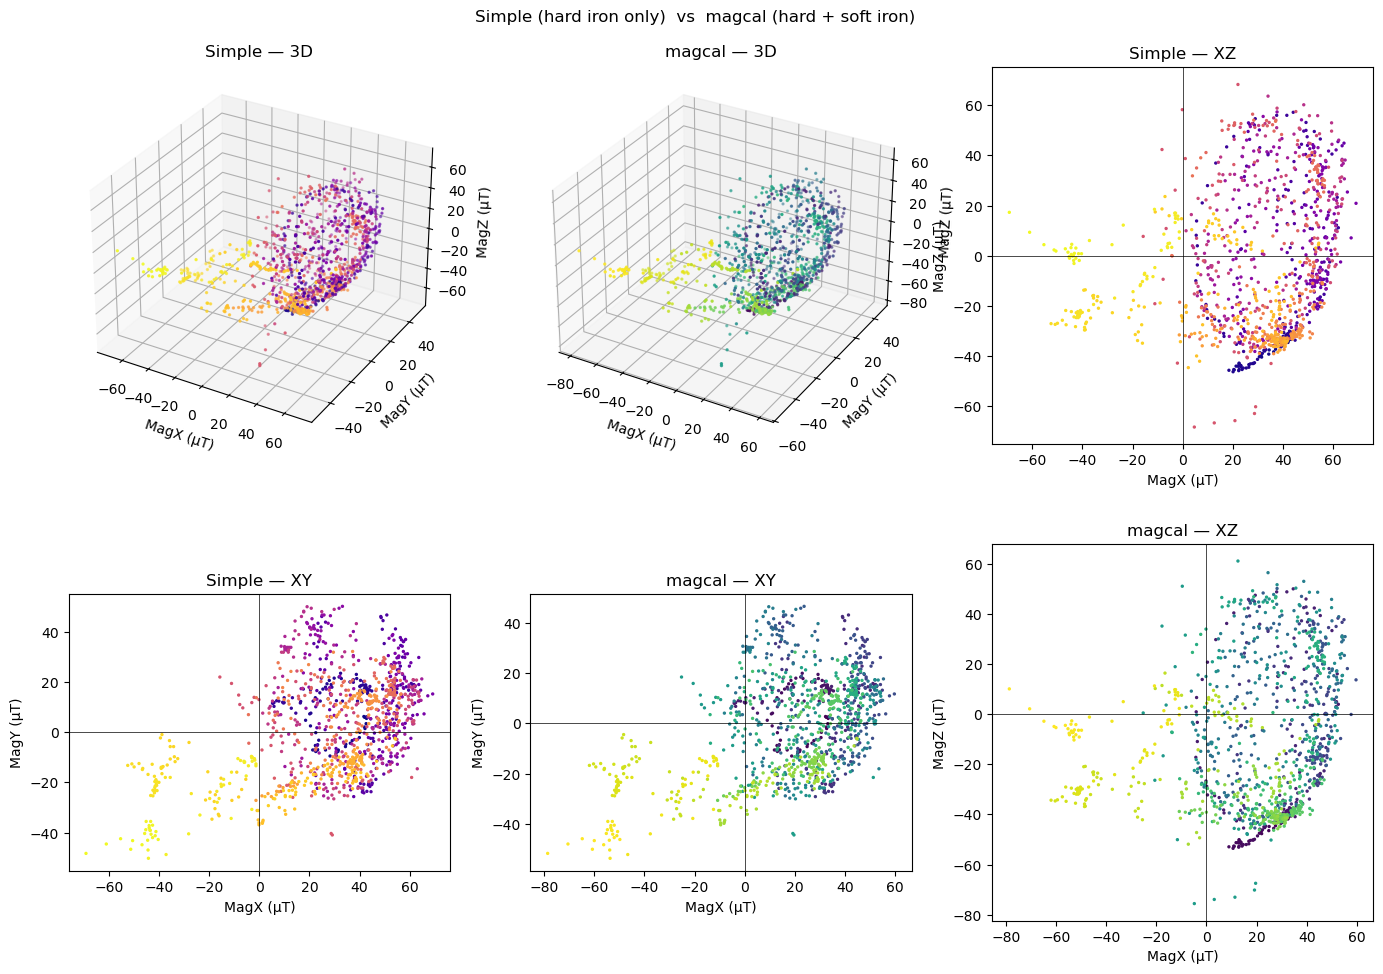

In [38]:
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Simple (hard iron only)  vs  magcal (hard + soft iron)', fontsize=12)

# Simple — 3D
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
ax1.scatter(mx_cal, my_cal, mz_cal, s=2, c=t, cmap='plasma')
ax1.set_title('Simple — 3D')
ax1.set_xlabel('MagX (µT)'); ax1.set_ylabel('MagY (µT)'); ax1.set_zlabel('MagZ (µT)')

# magcal — 3D
ax2 = fig.add_subplot(2, 3, 2, projection='3d')
ax2.scatter(mx_mc, my_mc, mz_mc, s=2, c=t, cmap='viridis')
ax2.set_title('magcal — 3D')
ax2.set_xlabel('MagX (µT)'); ax2.set_ylabel('MagY (µT)'); ax2.set_zlabel('MagZ (µT)')

# Simple — XY
ax3 = fig.add_subplot(2, 3, 4)
ax3.scatter(mx_cal, my_cal, s=2, c=t, cmap='plasma')
ax3.set_aspect('equal'); ax3.set_title('Simple — XY')
ax3.set_xlabel('MagX (µT)'); ax3.set_ylabel('MagY (µT)')
ax3.axhline(0, color='k', lw=0.5); ax3.axvline(0, color='k', lw=0.5)

# magcal — XY
ax4 = fig.add_subplot(2, 3, 5)
ax4.scatter(mx_mc, my_mc, s=2, c=t, cmap='viridis')
ax4.set_aspect('equal'); ax4.set_title('magcal — XY')
ax4.set_xlabel('MagX (µT)'); ax4.set_ylabel('MagY (µT)')
ax4.axhline(0, color='k', lw=0.5); ax4.axvline(0, color='k', lw=0.5)

# Simple — XZ
ax5 = fig.add_subplot(2, 3, 3)
ax5.scatter(mx_cal, mz_cal, s=2, c=t, cmap='plasma')
ax5.set_aspect('equal'); ax5.set_title('Simple — XZ')
ax5.set_xlabel('MagX (µT)'); ax5.set_ylabel('MagZ (µT)')
ax5.axhline(0, color='k', lw=0.5); ax5.axvline(0, color='k', lw=0.5)

# magcal — XZ
ax6 = fig.add_subplot(2, 3, 6)
ax6.scatter(mx_mc, mz_mc, s=2, c=t, cmap='viridis')
ax6.set_aspect('equal'); ax6.set_title('magcal — XZ')
ax6.set_xlabel('MagX (µT)'); ax6.set_ylabel('MagZ (µT)')
ax6.axhline(0, color='k', lw=0.5); ax6.axvline(0, color='k', lw=0.5)

plt.tight_layout()
plt.show()

## Step 6 — Record your calibration values

Write down your hard iron offsets — you will need them in the firmware and the sensor fusion notebook.

| Axis | Offset (µT) |
|------|-------------|
| X    |      59.725       |
| Y    |       6.680      |
| Z    |       -15.195      |

**Discussion questions:**
1. **Does your 3D scatter after calibration look like a sphere? If not, what shape is it and what might cause that?**

The calibrated 3D scatter doesn‘t look like a full sphere. It still looks like a partial curved shell or half-ellipsoid. This happens because the sensor was not rotated through all directions, so the calibration only used part of the magnetic field shape.

2. **How complete is your coverage of orientations? Are there gaps in the scatter plot?**

The orientation coverage is incomplete. There are clear gaps in the XY and XZ plots, especially on the negative X side. Most points are concentrated on one side of the plot, so the sensor did not cover a full 360° range.

3. **What happens to your heading estimate if you skip calibration?**

If calibration is skipped, the heading will be wrong because the magnetic field is shifted away from the center. The compass may seem correct in some directions, but in other directions the error can become large, sometimes tens of degrees.

---
---
---

# **Module D- Pendulum Test**

Consider:

**Which axis or axes show the oscillating signal? Why those and not the others?**

From the raw X, Y, Z accelerometer plot, all axes contain motion. For an ideal pendulum, the axis inline with the direction of swinging would have the largest recorded changes (such as Y). The other planar axis (X) would ideally have minimal or none recorded motion. The axis that is inline with Earth's gravity (Z) also displays some motion in a pendulum due to centrifugal force, and the angle offset from the gravitational vector as it swings up and down.

---

**How do you extract the measured period T from the data? There is more than one valid approach — consider both time-domain and frequency-domain methods.**
<br><br>
Two methods are used:
  1) Frequency-domain: FFT of the filtered PCA signal. Chosen frequency = 0.3155 Hz, so T_fft = 3.1692 s.
  2) Time-domain: average spacing between consecutive peaks of the filtered PCA signal, so T_time = 3.2745 s.

---

**How does your measured T compare to the value predicted from your measured L?**
<br><br>
Theoretical period: T_theory = 3.1488 s
FFT-based measured period: T_fft = 3.1692 s, error = 0.65 %
Time-domain measured period: T_time = 3.2745 s, error = 3.99 %

---

**The small-angle approximation breaks down for large release angles. Does your data show any sign of this (e.g., period lengthening at larger amplitudes)?**
<br><br>
Early average period = 3.5467 s
Late average period  = 3.1100 s
The early period is slightly larger than the late period, which suggests a small amount of period lengthening at larger amplitude.

---

**What is the frequency of the pendulum? How does it compare to typical ocean wave frequencies? What does this imply about using the accelerometer to sense waves?**
<br><br>
FFT-based pendulum frequency = 0.3155 Hz
Time-domain pendulum frequency = 0.3054 Hz
Typical ocean wave frequencies are often on the order of about 0.05 to 0.5 Hz,
so this pendulum frequency is of the same low-frequency scale.
This suggests an accelerometer can detect wave-like oscillations, but filtering and axis selection are important because raw signals contain gravity effects, rotation, and noise. Using the pendulum to calibrate the accelerometer will allow the accelerometer to be calibrated to the frequencies expected of ocean waves.

##**Part D Plots**
* Time-series of oscillating axis
* Period extraction and comparison to T = 2π√(L/g)
* PSD with labeled peak frequency

The period of a simple pendulum (small-angle approximation) is:

$$T = 2\pi\sqrt{\frac{L}{g}}$$

In [39]:
!pip install scikit-learn scipy

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks, detrend
from sklearn.decomposition import PCA

In [41]:
t_start = 12      # trim start time in seconds
t_end = 50        # trim end time in seconds

L = 2.4638        # pendulum length in meters
g = 9.81

# FFT search range
f_min_fft = 0.05
f_max_fft = 1.50

# PCA band-pass range
bp_low = 0.20
bp_high = 0.60

In [42]:
# Local filename
#filename = "imuLog00024.csv"
# Load from Google Drive
url='https://drive.google.com/file/d/1mhrXDocIXTn-QdamEOADehZQyVIFZDSE/view?usp=drive_link'
url='https://drive.google.com/uc?id=' + url.split('/')[-2]
data = pd.read_csv(url)
#data = pd.read_csv(filename)

# accelerometer: milli-g -> m/s^2
accX = data["AccX"].to_numpy() / 1000 * 9.81
accY = data["AccY"].to_numpy() / 1000 * 9.81
accZ = data["AccZ"].to_numpy() / 1000 * 9.81

# timestamps
timestamps = data["Timestamp"].astype(str).str.replace(" IMU", "", regex=False)
time_data = pd.to_datetime(timestamps, format="%Y/%m/%d %H:%M:%S.%f")
time_sec = (time_data - time_data.iloc[0]).dt.total_seconds().to_numpy()

print(f"Samples: {len(accX)}")
print(f"Duration: {time_sec.max():.2f} sec")

Samples: 547
Duration: 54.79 sec


In [43]:
T_theory = 2 * np.pi * np.sqrt(L / g)
f_theory = 1 / T_theory

print(f"Theoretical period    = {T_theory:.4f} s")
print(f"Theoretical frequency = {f_theory:.4f} Hz")

Theoretical period    = 3.1488 s
Theoretical frequency = 0.3176 Hz


Plot all three accelerometer axes

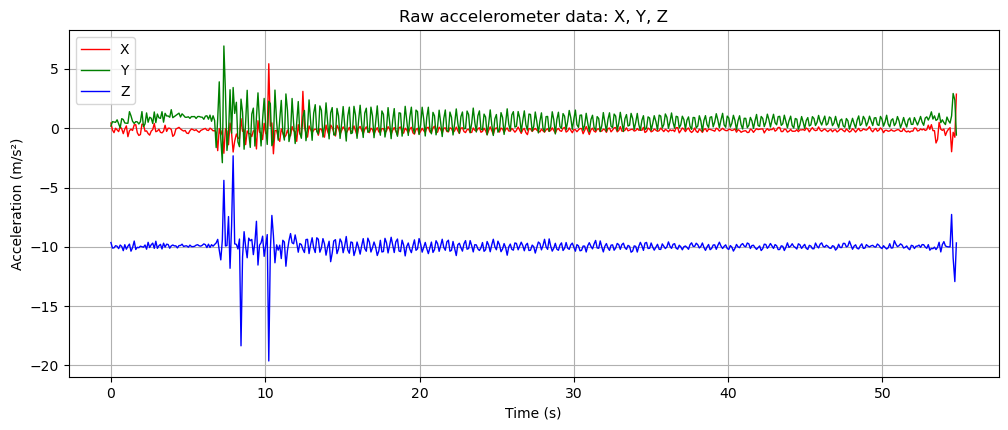

In [44]:
plt.figure(figsize=(12, 4.5))
plt.plot(time_sec, accX, "r", label="X", linewidth=1.0)
plt.plot(time_sec, accY, "g", label="Y", linewidth=1.0)
plt.plot(time_sec, accZ, "b", label="Z", linewidth=1.0)
plt.grid(True)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.title("Raw accelerometer data: X, Y, Z")
plt.legend()
plt.show()

Trim data and sampling frequency

In [45]:
idx = (time_sec >= t_start) & (time_sec <= t_end)

t_trim = time_sec[idx].copy()
t_trim = t_trim - t_trim[0]

ax = accX[idx]
ay = accY[idx]
az = accZ[idx]

Fs = 1 / np.mean(np.diff(t_trim))
print(f"Sampling frequency = {Fs:.3f} Hz")

Sampling frequency = 9.966 Hz


Detrend and PCA on horizontal motion

In [46]:
ax_d = detrend(ax)
ay_d = detrend(ay)
az_d = detrend(az)

XY = np.column_stack([ax_d, ay_d])

pca = PCA(n_components=2)
score = pca.fit_transform(XY)

pc1 = score[:, 0]   # dominant signed horizontal oscillation
pc2 = score[:, 1]

In [47]:
b, a = butter(4, [bp_low / (Fs / 2), bp_high / (Fs / 2)], btype="bandpass")
pc1_bp = filtfilt(b, a, pc1)

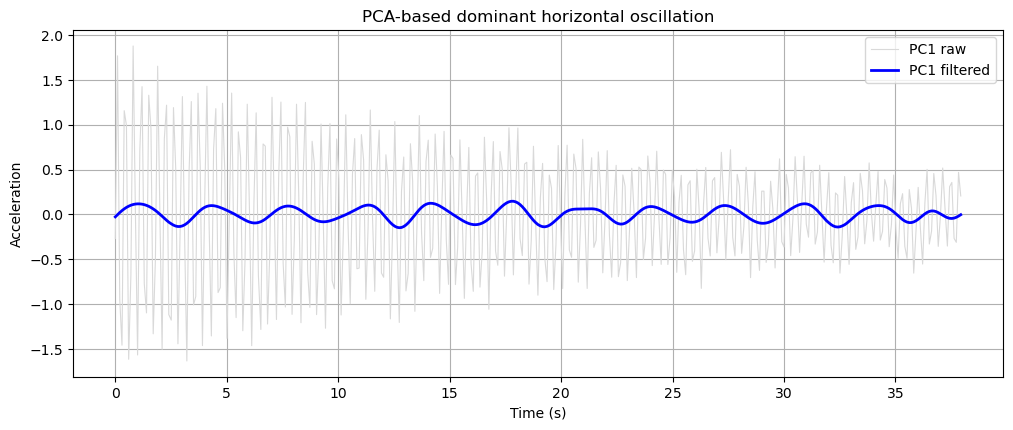

In [48]:
plt.figure(figsize=(12, 4.5))
plt.plot(t_trim, pc1, color="0.85", linewidth=0.8, label="PC1 raw")
plt.plot(t_trim, pc1_bp, "b", linewidth=2.0, label="PC1 filtered")
plt.grid(True)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.title("PCA-based dominant horizontal oscillation")
plt.legend()
plt.show()

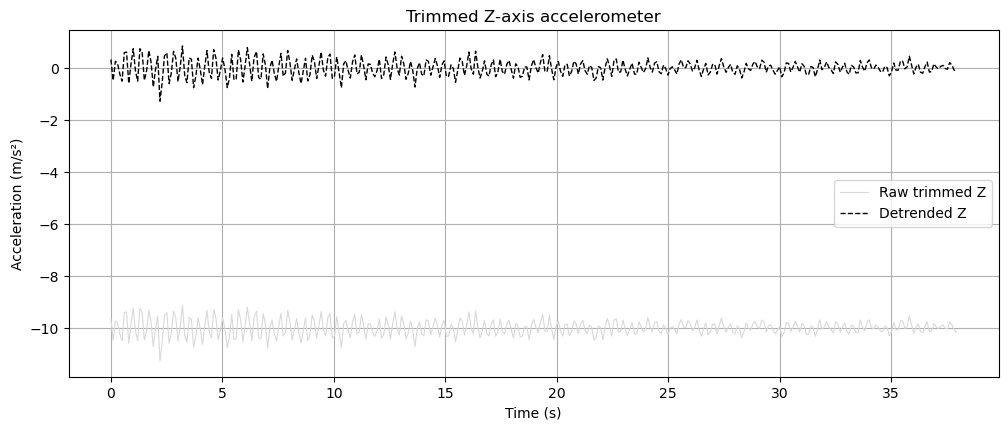

In [49]:
plt.figure(figsize=(12, 4.5))
plt.plot(t_trim, az, color="0.85", linewidth=0.8, label="Raw trimmed Z")
plt.plot(t_trim, az_d, "k--", linewidth=1.0, label="Detrended Z")
plt.grid(True)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration (m/s²)")
plt.title("Trimmed Z-axis accelerometer")
plt.legend()
plt.show()

In [50]:
N = len(pc1_bp)
f = np.fft.rfftfreq(N, d=1/Fs)
Pfft = np.fft.rfft(pc1_bp)
Pmag = np.abs(Pfft) / N

valid = (f >= f_min_fft) & (f <= f_max_fft)
f_valid = f[valid]
P_valid = Pmag[valid]

In [51]:
peaks_idx, _ = find_peaks(P_valid, prominence=0.05 * np.max(P_valid))

locsP = f_valid[peaks_idx]
pksP = P_valid[peaks_idx]

if len(locsP) == 0:
    raise ValueError("No FFT peaks found. Try adjusting the band-pass or prominence.")

ip_best = np.argmin(np.abs(locsP - f_theory))
f_p_fft = locsP[ip_best]
T_p_fft = 1 / f_p_fft

print(f"Chosen FFT frequency = {f_p_fft:.4f} Hz")
print(f"FFT period           = {T_p_fft:.4f} s")

Chosen FFT frequency = 0.3155 Hz
FFT period           = 3.1692 s


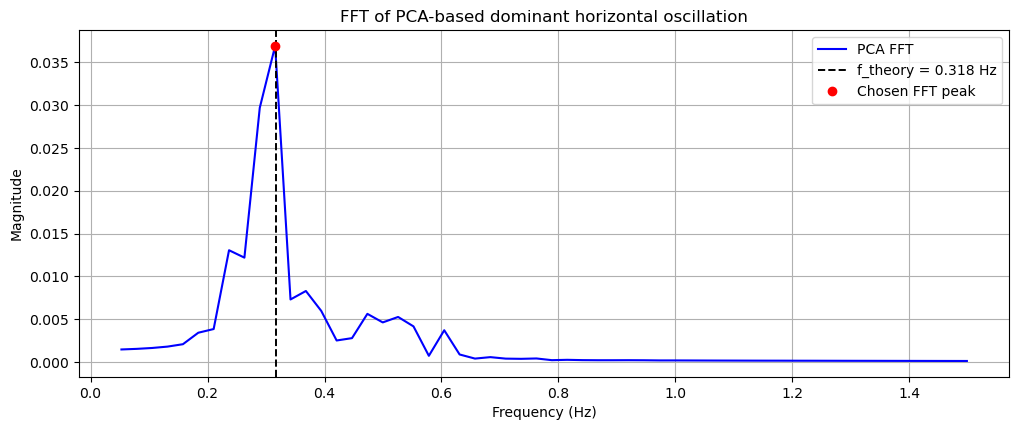

In [52]:
plt.figure(figsize=(12, 4.5))
plt.plot(f_valid, P_valid, "b", linewidth=1.5, label="PCA FFT")
plt.axvline(f_theory, color="k", linestyle="--", linewidth=1.4, label=f"f_theory = {f_theory:.3f} Hz")
plt.plot(f_p_fft, P_valid[np.argmin(np.abs(f_valid - f_p_fft))], "ro", label="Chosen FFT peak")
plt.grid(True)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title("FFT of PCA-based dominant horizontal oscillation")
plt.legend()
plt.show()

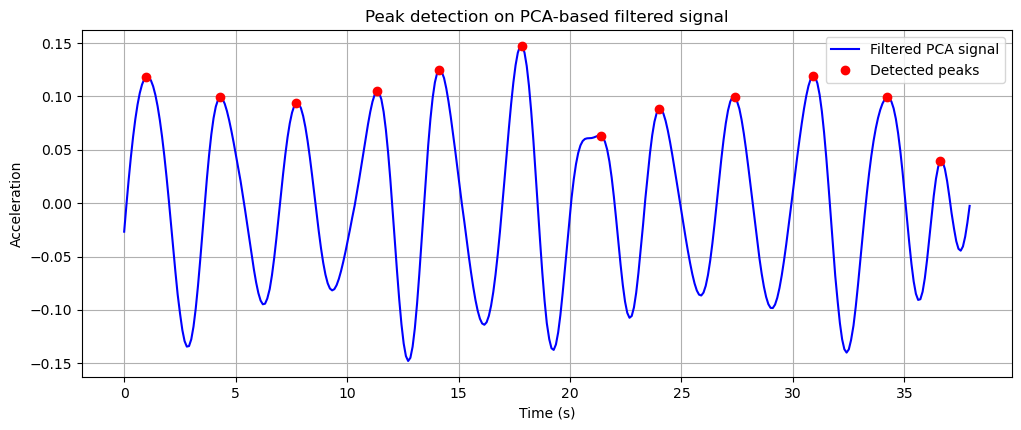

Time-domain period = 3.2382 s


In [53]:
peaks_time, props = find_peaks(
    pc1_bp,
    prominence=0.15 * np.std(pc1_bp),
    distance=0.8 * Fs
)

locs_pc1 = t_trim[peaks_time]
pks_pc1 = pc1_bp[peaks_time]

plt.figure(figsize=(12, 4.5))
plt.plot(t_trim, pc1_bp, "b", linewidth=1.5, label="Filtered PCA signal")
plt.plot(locs_pc1, pks_pc1, "ro", label="Detected peaks")
plt.grid(True)
plt.xlabel("Time (s)")
plt.ylabel("Acceleration")
plt.title("Peak detection on PCA-based filtered signal")
plt.legend()
plt.show()

if len(locs_pc1) >= 2:
    T_time = np.mean(np.diff(locs_pc1))
else:
    T_time = np.nan

print(f"Time-domain period = {T_time:.4f} s")

In [54]:
if len(locs_pc1) >= 6:
    periods = np.diff(locs_pc1)
    nseg = len(periods) // 3
    early_T = np.mean(periods[:nseg])
    late_T = np.mean(periods[-nseg:])
else:
    periods = np.array([])
    early_T = np.nan
    late_T = np.nan

print(f"Early average period = {early_T:.4f} s")
print(f"Late average period  = {late_T:.4f} s")

Early average period = 3.4467 s
Late average period  = 3.0767 s


In [55]:
err_fft = 100 * (T_p_fft - T_theory) / T_theory

if not np.isnan(T_time):
    err_time = 100 * (T_time - T_theory) / T_theory
    f_measured_time = 1 / T_time
else:
    err_time = np.nan
    f_measured_time = np.nan

f_measured_fft = f_p_fft

print(f"FFT error       = {err_fft:.2f} %")
print(f"Peak-time error = {err_time:.2f} %")
print(f"FFT frequency   = {f_measured_fft:.4f} Hz")
print(f"Time frequency  = {f_measured_time:.4f} Hz")

FFT error       = 0.65 %
Peak-time error = 2.84 %
FFT frequency   = 0.3155 Hz
Time frequency  = 0.3088 Hz


In [56]:
print("T_theory_s =", T_theory)
print("T_fft_s =", T_p_fft)
print("T_time_s =", T_time)

print("error_fft_percent =", err_fft)
print("error_time_percent =", err_time)

print("early_T_s =", early_T)
print("late_T_s =", late_T)

print("f_fft_Hz =", f_measured_fft)
print("f_time_Hz =", f_measured_time)

T_theory_s = 3.148821848080584
T_fft_s = 3.1691953262786594
T_time_s = 3.238181818181818
error_fft_percent = 0.6470190814540538
error_time_percent = 2.837885863746303
early_T_s = 3.4466666666666668
late_T_s = 3.0766666666666658
f_fft_Hz = 0.31553750938230196
f_time_Hz = 0.308815272318922


Code to convert notebook to PDF for exporting:

In [57]:
# Install LateX packages. Only run once! Already installed, so commented out
!apt-get install -y texlive-xetex texlive-fonts-recommended texlive-latex-extra

'apt-get' is not recognized as an internal or external command,
operable program or batch file.
